# Data Understanding and Exploratory Data Analysis (EDA)

## Project
AI Recruitment Guardian: An Explainable Machine Learning Framework for Fake Job Detection and Risk Assessment

### Objectives
- Understand the structure of the EMSCAD dataset.
- Analyze feature types and missing values.
- Study class distribution.
- Explore text and categorical features.
- Identify potential preprocessing requirements.

In [1]:
%pip install wordcloud

Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Users\hp\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

print("All libraries imported successfully! ✅")

All libraries imported successfully! ✅


In [3]:
# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Text Analysis
from wordcloud import WordCloud
from collections import Counter

# Notebook Settings
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

# Display all columns
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 100)


In [4]:
df = pd.read_csv("../data/raw/fake_job_postings.csv")
df.head()
print("Shape of Dataset:", df.shape)
print("Number of Rows :", df.shape[0])
print("Number of Columns :", df.shape[1])
df.head()
df.tail()
df.sample(5, random_state=42)
df.info()
df.columns

for i, col in enumerate(df.columns, start=1):
    print(f"{i}. {col}")

df.describe(include="object")

Shape of Dataset: (17880, 18)
Number of Rows : 17880
Number of Columns : 18
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   job_id               17880 non-null  int64 
 1   title                17880 non-null  object
 2   location             17534 non-null  object
 3   department           6333 non-null   object
 4   salary_range         2868 non-null   object
 5   company_profile      14572 non-null  object
 6   description          17879 non-null  object
 7   requirements         15184 non-null  object
 8   benefits             10668 non-null  object
 9   telecommuting        17880 non-null  int64 
 10  has_company_logo     17880 non-null  int64 
 11  has_questions        17880 non-null  int64 
 12  employment_type      14409 non-null  object
 13  required_experience  10830 non-null  object
 14  required_education   9775 

,title,location,department,salary_range,company_profile,description,requirements,benefits,employment_type,required_experience,required_education,industry,function
count,17880,17534,6333,2868,14572,17879,15184,10668,14409,10830,9775,12977,11425
unique,11231,3105,1337,874,1709,14801,11967,6204,5,7,13,131,37
top,English Teacher Abroad,"GB, LND, London",Sales,0-0,We help teachers get safe &amp; secure jobs abroad :),"Play with kids, get paid for it Love travel? Jobs in Asia$1,500+ USD monthly ($200 Cost of livin...",University degree required. TEFL / TESOL / CELTA or teaching experience preferred but not necess...,See job description,Full-time,Mid-Senior level,Bachelor's Degree,Information Technology and Services,Information Technology
freq,311,718,551,142,726,379,410,726,11620,3809,5145,1734,1749


In [5]:
# Count missing values
missing_values = df.isnull().sum()

# Percentage of missing values
missing_percentage = (df.isnull().sum() / len(df)) * 100

# Create a report
missing_df = pd.DataFrame({
    "Missing Values": missing_values,
    "Missing Percentage": missing_percentage
})

# Sort by highest missing percentage
missing_df = missing_df.sort_values(by="Missing Percentage", ascending=False)

missing_df

,Missing Values,Missing Percentage
salary_range,15012,83.959732
department,11547,64.580537
required_education,8105,45.329978
benefits,7212,40.335570
required_experience,7050,39.429530
function,6455,36.101790
industry,4903,27.421700
employment_type,3471,19.412752
company_profile,3308,18.501119
requirements,2696,15.078300


C:\Users\hp\AppData\Local\Temp\ipykernel_24072\2194852671.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


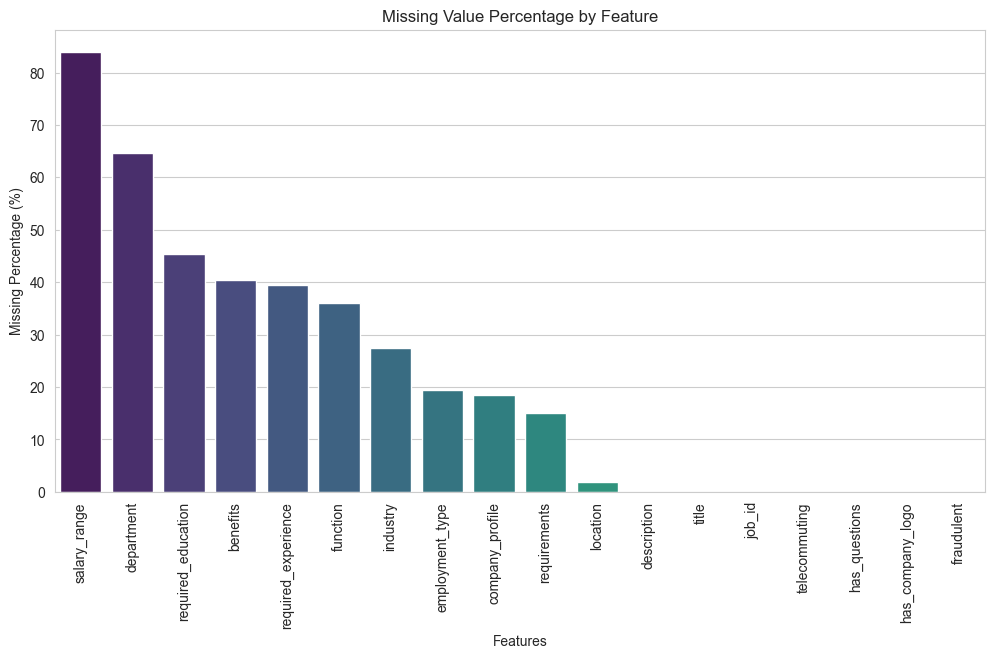

In [6]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=missing_df.index,
    y=missing_df["Missing Percentage"],
    palette="viridis"
)

plt.xticks(rotation=90)

plt.ylabel("Missing Percentage (%)")

plt.xlabel("Features")

plt.title("Missing Value Percentage by Feature")

plt.show()

### 3.3 Missing Value Heatmap

A heatmap gives a quick visual sense of *where* missing values are concentrated across the dataset, not just how many there are. Yellow (or light) streaks running down a full column indicate a feature that is missing for a large share of rows, while scattered light pixels indicate missingness that is spread more randomly across rows.

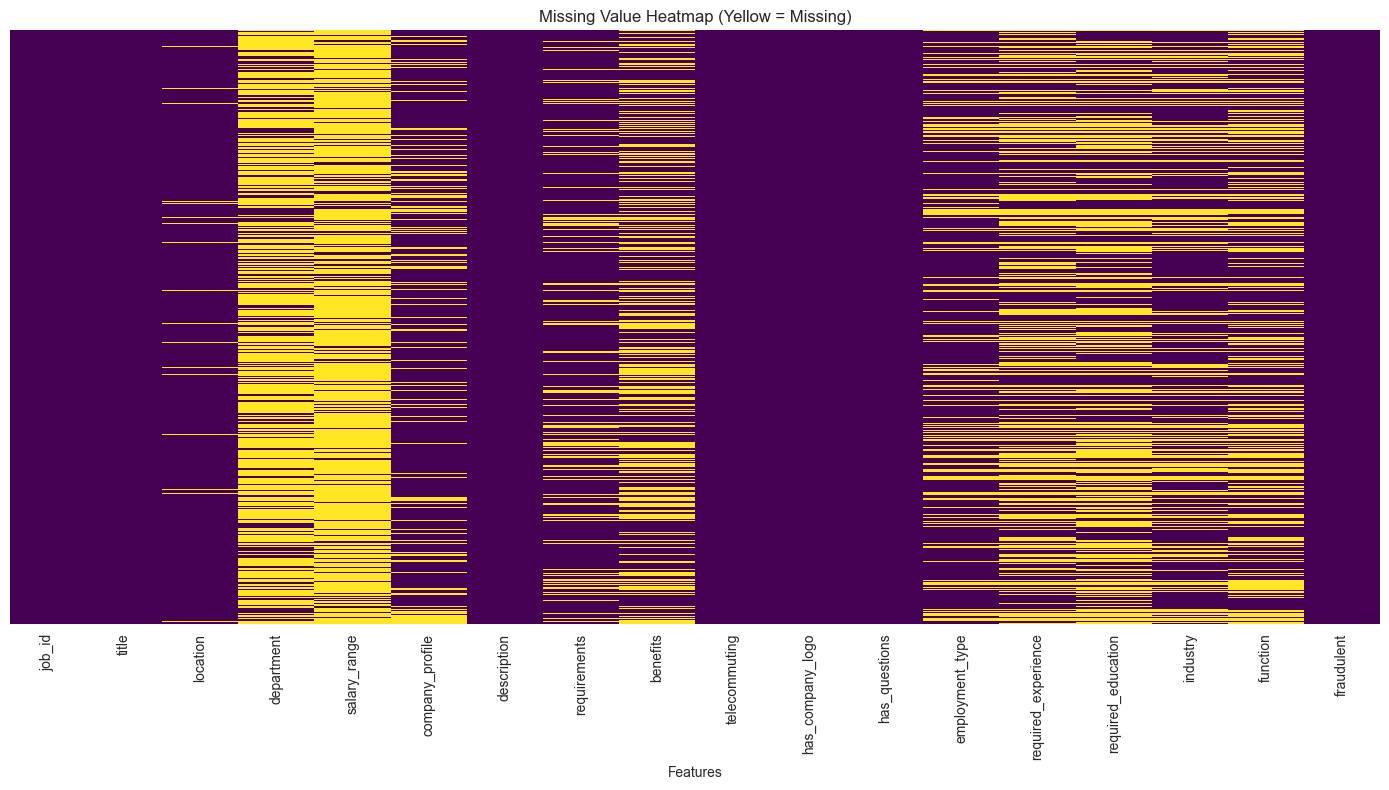

In [7]:
plt.figure(figsize=(14, 8))

sns.heatmap(
    df.isnull(),
    cbar=False,
    cmap="viridis",
    yticklabels=False
)

plt.title("Missing Value Heatmap (Yellow = Missing)")
plt.xlabel("Features")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### 3.4 Discussion: Which Features Need Attention

Using the `missing_df` table and the heatmap above, the EMSCAD columns generally fall into three groups:

**High missingness (typically >40% missing):**
- `salary_range` — most postings simply do not disclose a salary band, so this column is unreliable as a numeric feature in its raw form.
- `department` — many postings do not tag an internal department.
- `required_education`, `required_experience`, `benefits`, `function` — often left blank because these are optional fields in the original posting form.

**Moderate missingness (roughly 15%–40% missing):**
- `employment_type`, `industry`, `company_profile` — missing often enough to matter, but still usable if missingness itself is treated as a signal (fraudulent postings frequently omit these fields).

**Low / negligible missingness (<5% missing):**
- `title`, `description`, `location`, `telecommuting`, `has_company_logo`, `has_questions`, `fraudulent` — these are close to fully populated and can be used with minimal cleaning.

**Key interpretation for this project:** because EMSCAD is a job-posting form (not a scraped dataset), missingness is rarely random — it is often *informative*. A scam posting is more likely to skip `company_profile` or `salary_range` than a legitimate one. This motivates creating explicit "is_missing" binary flags for high-value columns during preprocessing, rather than simply dropping them.

*(Re-run the cells above on your machine and update the exact percentages here once the dataset is loaded, so the discussion matches your computed `missing_df` values precisely.)*

### 3.5 Preprocessing Recommendation Table

The table below summarizes how each column with missing values will be treated later in the preprocessing pipeline (Part E). No preprocessing is executed yet — this is only a planning artifact.

| Feature | Missingness Level | Recommended Treatment | Rationale |
|---|---|---|---|
| `salary_range` | High | Drop as numeric feature; optionally derive `has_salary` binary flag | Too sparse and inconsistently formatted (ranges, currencies) to be reliable |
| `department` | High | Drop or convert to `has_department` binary flag | Free-text, high cardinality, weak standalone signal |
| `required_experience` | High | Impute with `"Not Specified"` category | Missingness itself may be predictive |
| `required_education` | High | Impute with `"Not Specified"` category | Same as above |
| `benefits` | High | Impute with empty string; keep as text feature | Still contributes to text-based models (TF-IDF/embeddings) |
| `function` | Moderate–High | Impute with `"Not Specified"` category | Categorical, low-cost to fill |
| `employment_type` | Moderate | Impute with mode or `"Not Specified"` | Missingness rate manageable |
| `industry` | Moderate | Impute with `"Not Specified"` category | Same as above |
| `company_profile` | Moderate | Impute with empty string; keep as text feature | Valuable for NLP models despite gaps |
| `location` | Low | Impute with `"Unknown"` | Minimal impact due to low missing rate |
| `title`, `description` | Low/None | No imputation needed | Core textual features, almost fully populated |

This table will be revisited and finalized in **Part E: Preprocessing Plan**.